# ML Photometric Redshift Production -- Part I: Model Training

**Authors: Zhiyao Li** <zhiyaol@alumni.cmu.edu>, **Markus Michael Rau** <markusmichael.rau@googlemail.com>, **Rachel Mandelbaum** <rmandelb@andrew.cmu.edu>

We apply a Machine Learning Redshift Estimation algorithm to produce photometric redshift estimations for the simulated extragalactic catalog with magnitude errors (cosmoDC2_v1.1.4_small_photoz_magerr_10y)

In [1]:
%pylab inline

import sys
import numpy as np
from numpy.random import shuffle
from matplotlib import pyplot as plt
%matplotlib inline

from sklearn.ensemble import RandomForestClassifier
import itertools
import copy
from astropy.coordinates import SkyCoord
import pandas as pd

import change_path
import GCRCatalogs
from astropy.table import Table

Populating the interactive namespace from numpy and matplotlib


### Variable Definition

In [4]:
llinewidth = 3
label_fontsize = 18
title_fontsize = 22
legend_fontsize = 14
tick_fontsize = 14
ppointsize = 8
ccapsize = 12

n_bins = 101
z_min = 0
z_max = 3

galid_ind = 0
rz_ind = 1
tr_start = 4
tr_end = 16
mag_r_ind = tr_start + 2
mag_i_ind = tr_start + 6   # index of mag_i_obs

## Accessing and preprocesssing training and testing data

### Accessing the training set
We used Sam Schmidt's small subset from the CosmDC2v1.1.4 extragalactic catalog. We perform a cut on the training set with observed i-band magnitude brighter than 25.0 and redshift range between 0 and 3. The true redshift distributions of the training set is plotted below.

In [4]:
# Loading the training set

train_dat_dir = '/global/projecta/projectdirs/lsst/groups/PZ/PhotoZDC2/COSMODC2v1.1.4/10_year_error_estimates/TESTRUN/sample_cosmodc2_w10year_errors.dat'
train_data = np.loadtxt(train_dat_dir, skiprows=1)
format_train = np.delete(train_data,[16,17],1)

# shuffle training data
data_len = len(format_train)
data_rand_ind = np.random.choice(data_len,data_len,replace = False)
random_train = format_train[data_rand_ind]

# Limit to the range of reshift value we are inspecting
train_extra = random_train[(random_train[:,rz_ind] >= z_min) & (random_train[:,rz_ind] < z_max)] #appy to rows individually
training_size_extra = len(train_extra)

#delete no longer needed variables to free up memory
%xdel train_data
%xdel format_train
%xdel random_train
%xdel data_rand_ind

# cut training at mag_i_obs <= 25.0

train = train_extra[train_extra[:,mag_i_ind] <= 25.0]
training_size = len(train)

%xdel train_extra

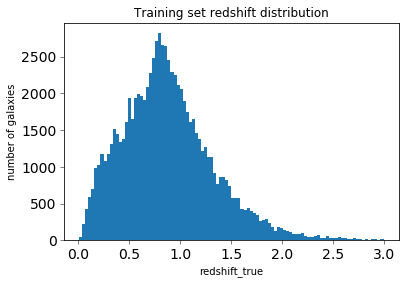

In [22]:
# Inspect redshift distribution in training set

dummy1 = plt.hist(train[:,1],100)
plt.xlabel('redshift_true')
plt.ylabel('number of galaxies')
plt.title('Training set redshift distribution')
xticks(np.arange(0, 3.1, step=0.5))
plt.tick_params(axis='both', which='major', length = 4, width = 0.5,labelsize=tick_fontsize,grid_linewidth=0.2)
%xdel dummy1

#larger axis

### Accessing the testing set
We use galaxies in the catalog cosmoDC2_v1.1.4_small_photoz_magerr_10y as our testing set.  This is the cosmoDC2_v1.1.4_small data with 10-year simulated photometric errors included.  We perform the same cutoff on the testing set as on the training set and only tested on galaxies with mag_i_obs brighter than 25.0. The magnitude distribution for the catalog along with this cut are plotted below. For each galaxy, we use observed magnitudes and errors of u, g, r, i, z, y band with photometric noises added.

In [6]:
# Acessing the testing catalogue

inquired_data = GCRCatalogs.load_catalog('cosmoDC2_v1.1.4_small_photoz_magerr_10y')


# Function that processes the inquired catalog with provided mag_filters
def process_testing_set(inquired_data, mag_filters):
    data_process = inquired_data.get_quantities(['galaxy_id','redshift_true','ra', 'dec', 'mag_u_obs','magerr_u_obs',
                                        'mag_g_obs','magerr_g_obs','mag_r_obs','magerr_r_obs','mag_i_obs',
                                        'magerr_i_obs','mag_z_obs','magerr_z_obs','mag_y_obs','magerr_y_obs'],
                                       filters=mag_filters)

    %xdel inquired_data

    data_process_1 = pd.DataFrame(data_process)

    %xdel data_process

    reordered_column = ['galaxy_id','redshift_true','ra', 'dec', 'mag_u_obs','magerr_u_obs','mag_g_obs','magerr_g_obs',
                       'mag_r_obs','magerr_r_obs','mag_i_obs','magerr_i_obs','mag_z_obs','magerr_z_obs',
                   'mag_y_obs','magerr_y_obs']
    data_process_2 = data_process_1[reordered_column]
    format_data = data_process_2.values

    %xdel data_process_1
    %xdel data_process_2

    # Limit to the range of reshift value we are inspecting
    cv = format_data[(format_data[:,rz_ind] >= z_min) & (format_data[:,rz_ind] < z_max)]
    testing_size = len(cv)
    return cv, testing_size


# Plot mag_i_obs distribution of the given dataset and location of the cut
def plot_i_dist(format_data):
    plt.hist(format_data[:,mag_i_ind],40,(15,28), log = True,histtype = 'step', label= 'Testing')
    plt.hist(train[:,mag_i_ind],40,(15,28),log = True, histtype = 'stepfilled', label = 'Training') 
    xlabel('Observed i-band magnitude',fontsize=tick_fontsize)
    ylabel('number of galaxies',fontsize=tick_fontsize)
    title('Observed i-band Magnitude Distribution')
    axvline(25.0,linewidth = 2,color = 'r',label = 'Magnitude Cut')
    #xticks(np.arange(0, 3.1, step=0.5))
    #yticks(np.arange(0, 1.5, step=0.2))
    plt.legend(loc = 'upper left')
    plt.tick_params(axis='both', which='major', length = 6, width = 2,labelsize=tick_fontsize,grid_linewidth=0.2)

/global/u1/z/zhiyaol/gcr-catalogs/GCRCatalogs/cosmodc2.py:362: H5pyDeprecationWarning: dataset.value has been deprecated. Use dataset[()] instead.
  yield lambda native_quantity: fh['{}/{}'.format(group, native_quantity)].value


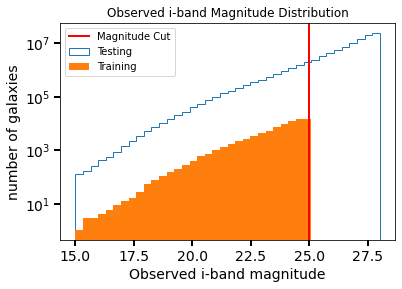

In [16]:
# inspect the i-band magnitude distribution of the uncut original catalog

mag_filters = []
original_set, original_size = process_testing_set(inquired_data, mag_filters)
plot_i_dist(original_set)

In [ ]:
# Process the inquired catalog to be used as testing set

mag_filters = [
    (np.isfinite, 'mag_i_obs'),
    'mag_i_obs < 25.0',] 

cv,  testing_size = process_testing_set(inquired_data, mag_filters)

### ML Model Training and Fitting
We split the redshift into 100 bins in true redshift (spec z). For every galaxy, we attempt to predict the probability in each bin. 

We use Random Forest Classifier from sklearn. (Scikit-learn: Machine Learning in Python, Pedregosa et al., JMLR 12, pp. 2825-2830, 2011.) as our machine learning algorithm. 

We train with 50 bootstrap samples to produce 50 models.

We apply these models to the testing set to obtain an average probability density vector for each galaxy as well as the redshift value of the bin with the biggest average probability. 


The result is in the format of a two-dimensional array, each entry being an individual galaxy, its identifying information, and its predicted average probability vector. For each model, we stack the predicted probability density functions of individual galaxies to obtain an ensemble distribution. We then take the average and standard deviation of the predicted distributions to provide ensemble results with errors. 

In [7]:
# Define Machine Learning method and train models to produce predictions

class ClassCond(object):
    def __init__(self, classifier, bins):
        self.bins = bins
        self.clf = classifier

    def fit(self, X, Y):
        self.Y = np.array(Y, dtype=np.double)
        grid_Y = np.linspace(z_min, z_max, num=self.bins)
        self.delta_z = grid_Y[1:] - grid_Y[:-1]
        self.midpoints = grid_Y[:-1] + self.delta_z/2
        self.response_classes = np.array(np.digitize(Y, bins=grid_Y), dtype=np.int) 
        #put edge cases in bins in range

        self.clf.fit(X=X, y=self.response_classes)

    def predict(self, X):
        nbatch = 10
        prob_vec = self.clf.predict_proba(X)
        #normalize the histogram to unit area (p * delta z)
        #prob vec is a matrix with each row being a galaxy and each column being a histogram bin height.
        result = prob_vec/(self.delta_z[0]) #on the premise that the grid is evenly spaced
        return result
    
    def ind_result(self,X):
        prob_vec = self.predict(X)
        each = sum(self.midpoints * prob_vec *(z_max/(n_bins-1)))
        
def multiple_train(times):
    prob_vec_table = np.zeros((testing_size,n_bins-1))
    syst_ave_table = []
    for i in range(times):
        training_ind = np.random.choice(training_size, training_size, replace = True)
        train_per = train[training_ind]
        model = ClassCond(RandomForestClassifier(n_jobs=10), bins=n_bins) 
        model.fit(train_per[:, tr_start:tr_end], train_per[:, rz_ind])
        prob_vec = model.predict(cv[:, tr_start:tr_end])
        prob_vec_table = prob_vec_table + np.array(prob_vec)      
        syst_ave = np.sum(prob_vec,axis = 0)/(len(cv))
        syst_ave_table += [syst_ave.tolist()]
    return prob_vec_table/times,np.array(syst_ave_table)

# Use 50 bootstrap samples of the training set to produce trained models

result,sys_ave = multiple_train(50)

### Write result

The ensemble result is stored at NERSC in '/global/projecta/projectdirs/lsst/groups/PZ/PhotoZDC2/COSMODC2v1.1.4/10_year_error_estimates/OLIVIA_WORK/result3_sys.fits

In [ ]:
# Output the mean and sigma in each bin for the entire ensemble

sys_ave.write('/global/projecta/projectdirs/lsst/groups/PZ/PhotoZDC2/COSMODC2v1.1.4/10_year_error_estimates/OLIVIA_WORK/result3_sys.fits')

The redshift estimation probability vectors for individual galaxies are stored at NERSC in '/global/projecta/projectdirs/lsst/groups/PZ/PhotoZDC2/COSMODC2v1.1.4/10_year_error_estimates/OLIVIA_WORK/result0.parquet'

Result includes the following columns

| Name of Column | Description                                                        |
|----------------|--------------------------------------------------------------------|
| galid          | Galaxy ID number                                                   |
| mag_i          | The observed i-band magnitude                                      |
| rz_real        | True redshift                                                      |
| photoz_mode    | The mode of predicted photometric redshift                         |
| photoz_pdf     | The probability density function of predicted photometric redshift |

In [13]:
# Get the z value with the highest probability (mode) for each galaxy

def get_ind_mode(ind_mean_table):
    one_vec = np.argmax(ind_mean_table,1)
    mode = []
    for i in range(len(one_vec)):
        mode += [midpoints[one_vec[i]]]
    return mode

mode_table = get_ind_mode(result)

# write results

output = Table([cv[:,galid_ind],cv[:,mag_i_ind], cv[:,rz_ind],mode_table, result],
               names = ('galid','mag_i','rz_real','photoz_mode','photoz_pdf'))

df = pd.DataFrame.from_records(output, columns=output.columns)
par_loc = '/global/projecta/projectdirs/lsst/groups/PZ/PhotoZDC2/COSMODC2v1.1.4/10_year_error_estimates/OLIVIA_WORK/final-result.parquet'
df.to_parquet(par_loc)